#  Document Similarity using TF-IDF

---

## Introduction

Document similarity is a technique used in Natural Language Processing (NLP) to measure how closely related two or more text documents are.

It helps us understand whether two documents talk about the same topic or contain similar meaning.

## Objectives
- Understand document similarity
- Learn TF-IDF representation
- Apply cosine similarity
- Build a simple similarity tool

### Why we need similarity in NLP
- To find related documents in search engines
- To recommend similar content
- To detect plagiarism
- To match resumes with job descriptions
- To improve chatbot responses

---

## TF-IDF Representation

TF-IDF (Term Frequency - Inverse Document Frequency) is a method to convert text into numerical vectors.

### How it works:
- **Term Frequency (TF):** Counts how often a word appears in a document
- **Inverse Document Frequency (IDF):** Reduces importance of common words across all documents

### Why TF-IDF is important:
- Converts text into machine-readable format
- Gives importance to meaningful words
- Reduces impact of common words like "is", "the", "and"

---

In [19]:
# Import required libraries
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
# Sample documents for comparison
documents = [
    "I love natural language processing",
    "Natural language processing is very powerful",
    "I enjoy machine learning and AI",
    "The weather is very sunny today"
]

# Print documents
for i, doc in enumerate(documents, 1):
    print(f"Document {i}: {doc}")

Document 1: I love natural language processing
Document 2: Natural language processing is very powerful
Document 3: I enjoy machine learning and AI
Document 4: The weather is very sunny today


In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

documents = [clean_text(doc) for doc in documents]

Convert Text to TF-IDF Vectors

In [18]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Convert documents into numerical vectors
tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF matrix created successfully.")

TF-IDF matrix created successfully.


## Cosine Similarity

Cosine similarity is a method used to measure how similar two document vectors are.

It calculates the **angle between two vectors** instead of their magnitude.

### How it works:
- Value ranges from **0 to 1**
- 1 → exactly similar documents
- 0 → completely different documents

---


Compute Cosine Similarity

In [4]:
# Calculate similarity between all documents
similarity_matrix = cosine_similarity(tfidf_matrix)

# Print similarity matrix
print("Cosine Similarity Matrix:\n")
print(similarity_matrix)

Cosine Similarity Matrix:

[[1.         0.54358614 0.         0.        ]
 [0.54358614 1.         0.         0.26787057]
 [0.         0.         1.         0.        ]
 [0.         0.26787057 0.         1.        ]]


Visualize Similarity

In [22]:
# Convert to DataFrame for better visualization
similarity_df = pd.DataFrame(
    similarity_matrix,
    columns=[f"Doc {i+1}" for i in range(len(documents))],
    index=[f"Doc {i+1}" for i in range(len(documents))]
)

print("Document Similarity Table:")
similarity_df

Document Similarity Table:


,Doc 1,Doc 2,Doc 3,Doc 4
Doc 1,1.000000,0.543586,0.0,0.000000
Doc 2,0.543586,1.000000,0.0,0.267871
Doc 3,0.000000,0.000000,1.0,0.000000
Doc 4,0.000000,0.267871,0.0,1.000000


Compare Two Specific Documents

In [12]:
# Compare Document 1 and Document 2
doc1 = tfidf_matrix[0]
doc2 = tfidf_matrix[1]

# Calculate similarity score
score = cosine_similarity(doc1, doc2)

print("Similarity between Doc1 and Doc2:")
print(score[0][0])

Similarity between Doc1 and Doc2:
0.543586136660141


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Take Document 1 as reference
doc1 = tfidf_matrix[0]

print("Similarity of Document 1 with other documents:\n")

# Loop through all documents
for i in range(tfidf_matrix.shape[0]):
    
    # Compare doc1 with each document
    score = cosine_similarity(doc1, tfidf_matrix[i])
    
    print(f"Doc1 vs Doc{i+1}: {score[0][0]:.3f}")

Similarity of Document 1 with other documents:

Doc1 vs Doc1: 1.000
Doc1 vs Doc2: 0.544
Doc1 vs Doc3: 0.000
Doc1 vs Doc4: 0.000


## Document Similarity Tool

A document similarity tool is a simple NLP application that:
- Takes multiple text documents
- Converts them into TF-IDF vectors
- Computes similarity between them
- Returns similarity scores

This acts like a mini search engine or recommendation system.

---

In [ ]:
#Simple Document Similarity Tool

def get_similarity(doc_a, doc_b):
    # Convert input documents into list
    docs = [doc_a, doc_b]
    
    # TF-IDF conversion
    vec = TfidfVectorizer()
    tfidf = vec.fit_transform(docs)
    
    # Cosine similarity
    score = cosine_similarity(tfidf[0], tfidf[1])
    
    return score[0][0]

# Test the tool
doc_a = "I love NLP and machine learning"
doc_b = "Machine learning and NLP are amazing"

print("Similarity Score:")
print(get_similarity(doc_a, doc_b))

Similarity Score:
0.5803329846765686


## Result Interpretation

The similarity score ranges from 0 to 1.

- 1 → Documents are identical
- 0 → Documents are completely different
- Values closer to 1 indicate higher similarity

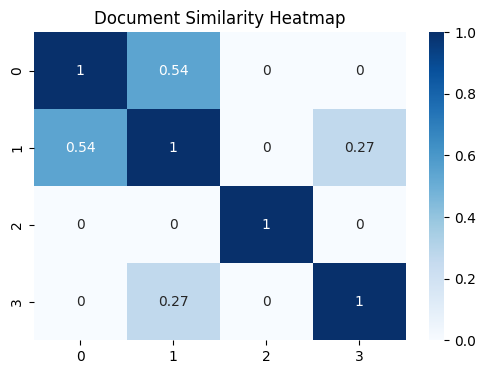

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(similarity_matrix, annot=True, cmap="Blues")
plt.title("Document Similarity Heatmap")
plt.show()

## Observations
- Similar documents have higher scores
- Different topics have low scores
- TF-IDF improves text representation

## Applications

- Search engines
- Recommendation systems
- Chatbots
- Plagiarism detection
- Resume matching systems

## Conclusion

TF-IDF combined with cosine similarity provides a simple yet powerful method for measuring document similarity. It is widely used in search engines, recommendation systems, and NLP applications.